# 02 — SP Type Classifier

This notebook trains CPP-based one-vs-rest classifiers for signal peptide type prediction.

The pipeline follows the cleaned terminology used in this repository:

- `pre_cs`: sequence region before the annotated cleavage site
- `post_cs`: sequence region after the annotated cleavage site
- `cs_position`: annotated cleavage-site position

The workflow is:

1. Load the parsed SignalP 6.0 dataset
2. Keep true SP sequences only
3. Split SP sequences into train/test sets stratified by SP type
4. Train one-vs-rest CPP classifiers for each SP type
5. Convert OVR probabilities into multiclass SP type predictions
6. Optionally refine difficult pairwise decisions:
   - `LIPO` vs `TATLIPO`
   - `SP` vs `TAT`

## 1. Imports

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import aaanalysis as aa
import aaanalysis.utils as ut

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


aa.options["verbose"] = False
aa.options["random_state"] = 42

## 2. Paths and configuration

This notebook uses `dataset_parsed.csv` created by `scripts/01_preprocess_signalp6.py`.

Filtering and balancing are performed explicitly inside this notebook to make the experimental setup clear.

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_parsed.csv"

FEATURE_DIR = PROJECT_ROOT / "features"
MODEL_DIR = PROJECT_ROOT / "models"
PLOT_DIR = PROJECT_ROOT / "plots"
METRIC_DIR = PROJECT_ROOT / "results" / "metrics"

for d in [
    FEATURE_DIR / "metadata",
    FEATURE_DIR / "matrices",
    FEATURE_DIR / "indices",
    MODEL_DIR,
    PLOT_DIR,
    METRIC_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_RUNS = 10

MIN_PRE_CS_LEN = 5
POST_CS_LEN = 15
PRE_CS_LEN_FOR_PLOTS = 24
MAX_COR = 0.5

SP_TYPES = ["SP", "LIPO", "TAT", "TATLIPO", "PILIN"]
OVR_NEG_POS_RATIO = 8

## 3. Load parsed dataset

Required columns:

- `entry`
- `kingdom`
- `sp_type`
- `sequence`
- `annotation`
- `label_binary`
- `cs_position`
- `pre_cs`
- `post_cs`
- `pre_cs_len`
- `post_cs_len`

In [3]:
def load_parsed_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = [
        "entry",
        "kingdom",
        "sp_type",
        "sequence",
        "annotation",
        "label_binary",
        "cs_position",
        "pre_cs",
        "post_cs",
        "pre_cs_len",
        "post_cs_len",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.copy()
    df["label_binary"] = df["label_binary"].astype(int)
    df["pre_cs"] = df["pre_cs"].astype(str)
    df["post_cs"] = df["post_cs"].astype(str)

    return df


df_seq = load_parsed_dataset(DATA_PATH)

# Same biological coverage choice as the binary classifier notebook.
df_seq = df_seq[df_seq["pre_cs_len"] >= MIN_PRE_CS_LEN].copy().reset_index(drop=True)

print(df_seq.shape)
print(df_seq["label_binary"].value_counts())
print(df_seq["sp_type"].value_counts())

(20287, 12)
label_binary
0    15625
1     4662
Name: count, dtype: int64
sp_type
NO_SP      15625
SP          2582
LIPO        1615
TAT          365
PILIN         67
TATLIPO       33
Name: count, dtype: int64


## 4. Build SP-only train/test sets

The SP type classifier is trained only on true SP sequences. The train/test split is stratified by `sp_type` to keep rare classes such as `PILIN` and `TATLIPO` represented in both sets.

In [4]:
df_sp = df_seq[df_seq["label_binary"] == 1].copy().reset_index(drop=True)
df_sp = df_sp[df_sp["sp_type"].isin(SP_TYPES)].copy().reset_index(drop=True)

train_sp_df, test_sp_df = train_test_split(
    df_sp,
    test_size=TEST_SIZE,
    stratify=df_sp["sp_type"],
    random_state=RANDOM_STATE,
)

train_sp_df = train_sp_df.reset_index(drop=True)
test_sp_df = test_sp_df.reset_index(drop=True)

print("Train SP type counts:")
print(train_sp_df["sp_type"].value_counts())

print("\nTest SP type counts:")
print(test_sp_df["sp_type"].value_counts())

Train SP type counts:
sp_type
SP         2065
LIPO       1292
TAT         292
PILIN        54
TATLIPO      26
Name: count, dtype: int64

Test SP type counts:
sp_type
SP         517
LIPO       323
TAT         73
PILIN       13
TATLIPO      7
Name: count, dtype: int64


## 5. Load AA scales and define CPP adapter

The cleaned dataset uses `pre_cs` and `post_cs`, but the AAanalysis CPP implementation expects internal part names such as `tmd` and `jmd_c`.

Therefore, the columns are mapped only at the CPP interface:

- `tmd` = `pre_cs`
- `jmd_c` = `post_cs`

In [8]:
df_scales = aa.load_scales()

# Redundancy-reduced scale set, matching the style of the original experiments.
aac = aa.AAclust()
X_scales = np.array(df_scales).T
selected_scales = aac.fit(
    X_scales,
    names=list(df_scales),
    n_clusters=100,
).medoid_names_
df_scales = df_scales[selected_scales]

sf = aa.SequenceFeature()

split_kws = {
    "Segment": {
        "n_split_min": 1,
        "n_split_max": 5,
    },
    "Pattern": {
        "steps": [3, 4],
        "n_min": 1,
        "n_max": 2,
        "len_max": 5,
    },
    "PeriodicPattern": {
        "steps": [3, 4],
    },
}


def to_cpp_parts(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.rename(columns={"pre_cs": "tmd", "post_cs": "jmd_c"})
        [["tmd", "jmd_c"]]
        .copy()
    )

## 6. Helper functions for OVR type classifiers

For each SP type, a one-vs-rest dataset is built from the SP-only training set.

To reduce class imbalance, negatives are randomly subsampled after the train/test split. The default ratio is `1 : 8` for positive : negative samples, following the original experimental direction.

In [12]:
def build_ovr_train_set(
    df_train: pd.DataFrame,
    target_type: str,
    neg_pos_ratio: int = OVR_NEG_POS_RATIO,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    df_tmp = df_train.copy()
    df_tmp["ovr_label"] = (df_tmp["sp_type"] == target_type).astype(int)

    df_pos = df_tmp[df_tmp["ovr_label"] == 1].copy()
    df_neg = df_tmp[df_tmp["ovr_label"] == 0].copy()

    if len(df_pos) == 0:
        raise ValueError(f"No positive samples found for target_type={target_type}")

    n_neg = min(len(df_neg), len(df_pos) * neg_pos_ratio)

    df_neg_sampled = df_neg.sample(
        n=n_neg,
        random_state=random_state,
    )

    return (
        pd.concat([df_pos, df_neg_sampled], ignore_index=True)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )


def build_ovr_test_set(
    df_test: pd.DataFrame,
    target_type: str,
) -> pd.DataFrame:
    df_tmp = df_test.copy()
    df_tmp["ovr_label"] = (df_tmp["sp_type"] == target_type).astype(int)

    return df_tmp.reset_index(drop=True)


def run_cpp_feature_selection(
    df_train_ovr: pd.DataFrame,
) -> pd.DataFrame:
    y = df_train_ovr["ovr_label"].values
    df_parts = to_cpp_parts(df_train_ovr)

    cpp = aa.CPP(
        df_scales=df_scales,
        df_parts=df_parts,
        split_kws=split_kws,
        accept_gaps=True,
    )

    df_feat = cpp.run(
        labels=y,
        jmd_n_len=0,
        jmd_c_len=POST_CS_LEN,
        max_cor=MAX_COR,
    )

    return df_feat


def make_feature_matrix(
    df_data: pd.DataFrame,
    df_feat: pd.DataFrame,
) -> np.ndarray:
    return sf.feature_matrix(
        df_parts=to_cpp_parts(df_data),
        features=df_feat["feature"],
        accept_gaps=True,
    )

## 7. Extract CPP features for each one-vs-rest classifier

Rare SP types such as PILIN were trained with a less aggressive negative subsampling ratio to preserve sufficient comparison diversity during OVR CPP feature selection.

In [13]:
## OVR CPP feature selection

OVR_NEG_POS_RATIOS = {
    "SP": 2,
    "LIPO": 2,
    "TAT": 2,
    "TATLIPO": 2,
    "PILIN": 3,
}

ovr_data = {}
ovr_features = {}

try:
    iterator = tqdm(SP_TYPES, desc="CPP OVR feature selection")
except NameError:
    iterator = SP_TYPES

for sp_type in iterator:
    print(f"\n=== CPP features: {sp_type} vs rest ===")

    neg_pos_ratio = OVR_NEG_POS_RATIOS.get(sp_type, OVR_NEG_POS_RATIO)

    train_ovr = build_ovr_train_set(
        train_sp_df,
        target_type=sp_type,
        neg_pos_ratio=neg_pos_ratio,
        random_state=RANDOM_STATE,
    )

    test_ovr = build_ovr_test_set(
        test_sp_df,
        target_type=sp_type,
    )

    df_feat_type = run_cpp_feature_selection(train_ovr)

    ovr_data[sp_type] = {
        "train": train_ovr,
        "test": test_ovr,
        "neg_pos_ratio": neg_pos_ratio,
    }

    ovr_features[sp_type] = df_feat_type

    feature_path = FEATURE_DIR / "metadata" / f"features_ovr_{sp_type}.csv"
    df_feat_type.to_csv(feature_path, index=False)

    print("neg_pos_ratio:", neg_pos_ratio)
    print("train:", train_ovr["ovr_label"].value_counts().to_dict())
    print("test:", test_ovr["ovr_label"].value_counts().to_dict())
    print("n_features:", len(df_feat_type))
    print("saved:", feature_path)

CPP OVR feature selection:   0%|          | 0/5 [00:00<?, ?it/s]


=== CPP features: SP vs rest ===
neg_pos_ratio: 2
train: {1: 2065, 0: 1664}
test: {1: 517, 0: 416}
n_features: 75
saved: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/features/metadata/features_ovr_SP.csv

=== CPP features: LIPO vs rest ===
neg_pos_ratio: 2
train: {0: 2437, 1: 1292}
test: {0: 610, 1: 323}
n_features: 100
saved: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/features/metadata/features_ovr_LIPO.csv

=== CPP features: TAT vs rest ===
neg_pos_ratio: 2
train: {0: 584, 1: 292}
test: {0: 860, 1: 73}
n_features: 63
saved: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/features/metadata/features_ovr_TAT.csv

=== CPP features: TATLIPO vs rest ===
neg_pos_ratio: 2
train: {0: 52, 1: 26}
test: {0: 926, 1: 7}
n_features: 72
saved: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desk

## 8. Compare models for each OVR classifier

Each OVR classifier is evaluated over repeated runs. The test set remains the original SP-only test set, while each training set is balanced by negative subsampling.

OVR model comparison:   0%|          | 0/5 [00:00<?, ?it/s]

/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LG

,sp_type,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
2,LIPO,LightGBM,0.997856,0.000000,0.993846,0.000000,1.000000,0.000000,0.996914,0.000000
1,LIPO,ExtraTrees,0.996677,0.000339,0.990495,0.000958,1.000000,0.000000,0.995224,0.000484
4,LIPO,Random Forest,0.996677,0.000791,0.991099,0.001728,0.999381,0.001305,0.995222,0.001137
5,LIPO,XGBoost,0.996570,0.001107,0.993823,0.000020,0.996285,0.003198,0.995050,0.001604
0,LIPO,CatBoost,0.995391,0.000723,0.987758,0.001424,0.999071,0.001495,0.993382,0.001040
3,LIPO,Logistic Regression,0.991426,0.000000,0.975831,0.000000,1.000000,0.000000,0.987768,0.000000
7,PILIN,ExtraTrees,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
9,PILIN,Logistic Regression,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
6,PILIN,CatBoost,0.998499,0.000904,0.905714,0.055750,1.000000,0.000000,0.949735,0.029982
10,PILIN,Random Forest,0.998071,0.000452,0.879048,0.026101,1.000000,0.000000,0.935450,0.014501


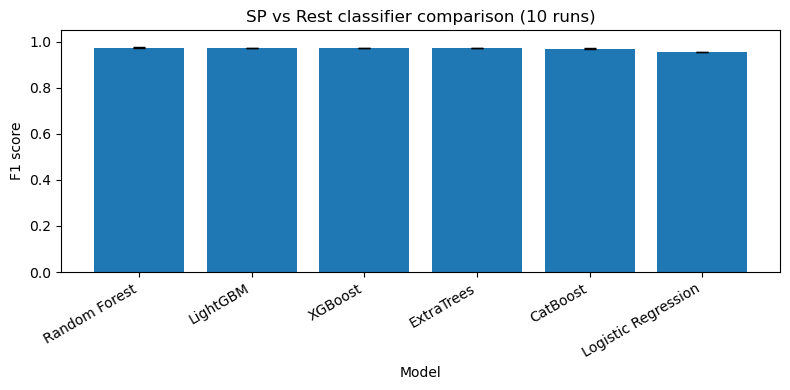

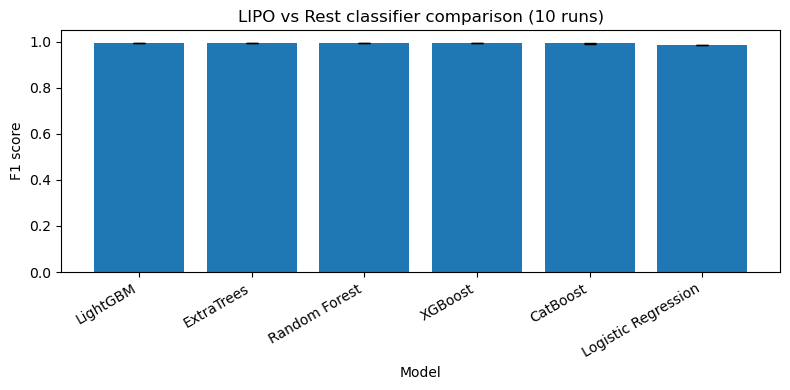

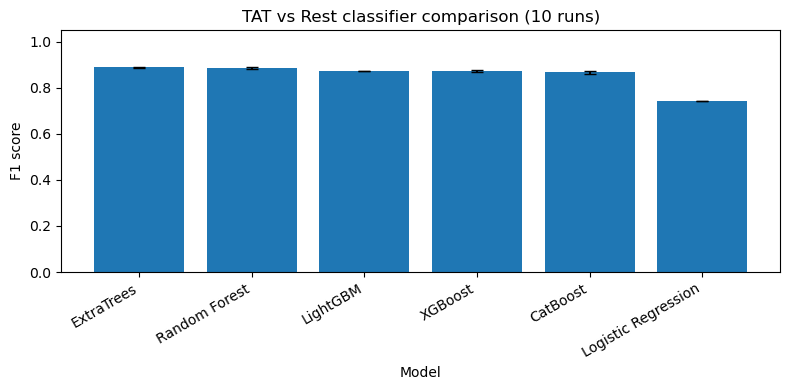

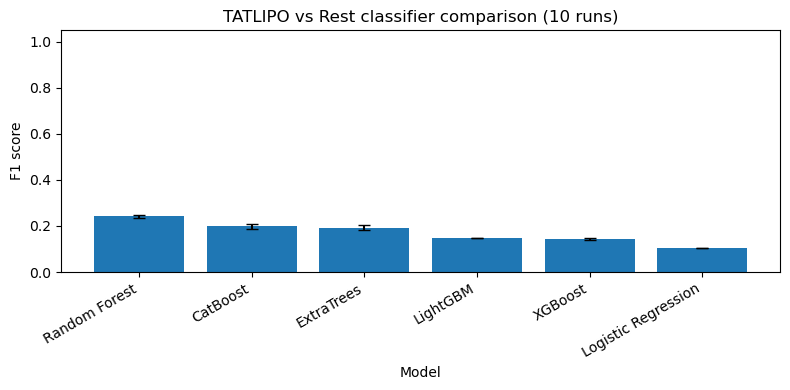

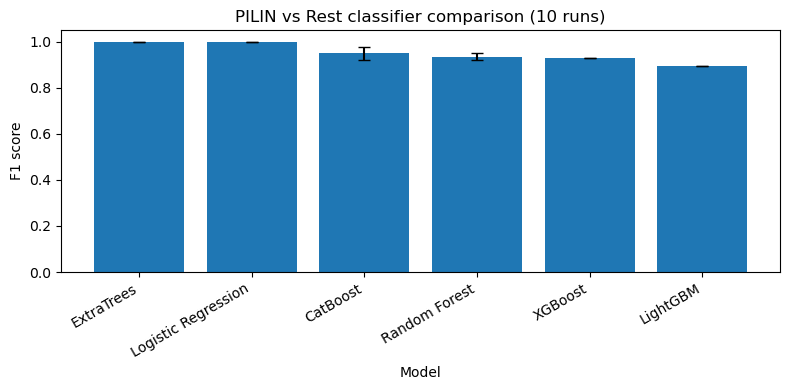

Saved run-level results to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/results/metrics/sp_type_ovr_model_runs.csv
Saved summary to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/results/metrics/sp_type_ovr_model_summary.csv


In [15]:
def get_ovr_models(seed: int, y_train: np.ndarray):
    pos = int((y_train == 1).sum())
    neg = int((y_train == 0).sum())
    scale_pos_weight = neg / max(pos, 1)

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
        ),
    }

    if XGBClassifier is not None:
        models["XGBoost"] = XGBClassifier(
            n_estimators=800,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
        )

    if LGBMClassifier is not None:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=800,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        )

    if CatBoostClassifier is not None:
        models["CatBoost"] = CatBoostClassifier(
            iterations=800,
            learning_rate=0.05,
            depth=6,
            auto_class_weights="Balanced",
            random_state=seed,
            verbose=False,
        )

    return models


def evaluate_binary_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }


ovr_runs = []
ovr_matrices = {}

try:
    outer = tqdm(SP_TYPES, desc="OVR model comparison")
except NameError:
    outer = SP_TYPES

for sp_type in outer:
    train_ovr = ovr_data[sp_type]["train"]
    test_ovr = ovr_data[sp_type]["test"]
    df_feat_type = ovr_features[sp_type]

    X_train_t = make_feature_matrix(train_ovr, df_feat_type)
    y_train_t = train_ovr["ovr_label"].values

    X_test_t = make_feature_matrix(test_ovr, df_feat_type)
    y_test_t = test_ovr["ovr_label"].values

    ovr_matrices[sp_type] = {
        "X_train": X_train_t,
        "y_train": y_train_t,
        "X_test": X_test_t,
        "y_test": y_test_t,
        "features": df_feat_type,
    }

    for run_idx in range(N_RUNS):
        seed = RANDOM_STATE + run_idx

        for model_name, model in get_ovr_models(seed, y_train_t).items():
            metrics = evaluate_binary_model(
                model,
                X_train_t,
                y_train_t,
                X_test_t,
                y_test_t,
            )

            ovr_runs.append(
                {
                    "sp_type": sp_type,
                    "run": run_idx,
                    "model": model_name,
                    **metrics,
                }
            )


ovr_runs_df = pd.DataFrame(ovr_runs)

ovr_summary = (
    ovr_runs_df
    .groupby(["sp_type", "model"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .reset_index()
    .sort_values(["sp_type", "f1_mean"], ascending=[True, False])
)

ovr_runs_path = METRIC_DIR / "sp_type_ovr_model_runs.csv"
ovr_summary_path = METRIC_DIR / "sp_type_ovr_model_summary.csv"

ovr_runs_df.to_csv(ovr_runs_path, index=False)
ovr_summary.to_csv(ovr_summary_path, index=False)

display(ovr_summary)


# Plot F1 comparison with error bars for each OVR task
for sp_type in SP_TYPES:
    plot_df = (
        ovr_summary[ovr_summary["sp_type"] == sp_type]
        .sort_values("f1_mean", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(8, 4))

    plt.bar(
        plot_df["model"],
        plot_df["f1_mean"],
        yerr=plot_df["f1_std"],
        capsize=4,
    )

    plt.ylabel("F1 score")
    plt.xlabel("Model")
    plt.title(f"{sp_type} vs Rest classifier comparison ({N_RUNS} runs)")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plot_path = PLOT_DIR / f"ovr_model_f1_comparison_{sp_type}.png"

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

print(f"Saved run-level results to: {ovr_runs_path}")
print(f"Saved summary to: {ovr_summary_path}")

### Best OVR models

The table below summarizes the best-performing classifier for each SP type in the one-vs-rest setting.

In [16]:
## Best OVR models by SP type

best_ovr_rows = (
    ovr_summary
    .sort_values(
        ["sp_type", "f1_mean"],
        ascending=[True, False],
    )
    .groupby("sp_type", as_index=False)
    .first()
)

best_ovr_rows = best_ovr_rows[
    [
        "sp_type",
        "model",
        "f1_mean",
        "f1_std",
        "accuracy_mean",
        "precision_mean",
        "recall_mean",
    ]
]

best_ovr_rows.to_csv(
    METRIC_DIR / "sp_type_best_ovr_models.csv",
    index=False,
)

display(best_ovr_rows)

,sp_type,model,f1_mean,f1_std,accuracy_mean,precision_mean,recall_mean
0,LIPO,LightGBM,0.996914,0.000000,0.997856,0.993846,1.000000
1,PILIN,ExtraTrees,1.000000,0.000000,1.000000,1.000000,1.000000
2,SP,Random Forest,0.974345,0.001442,0.971168,0.961057,0.988008
3,TAT,ExtraTrees,0.888765,0.003365,0.980493,0.802512,0.995890
4,TATLIPO,Random Forest,0.241964,0.006764,0.952947,0.137648,1.000000


## 10. Final OVR type prediction

For each SP type, the best-performing OVR classifier was retrained on its corresponding balanced OVR training set.

The final SP type prediction was obtained by selecting the type with the highest OVR probability score.

In [17]:
def instantiate_model_by_name(
    model_name: str,
    seed: int,
    y_train: np.ndarray,
):
    return get_ovr_models(seed, y_train)[model_name]


final_ovr_models = {}

ovr_test_proba = pd.DataFrame(
    index=range(len(test_sp_df))
)

for _, row in best_ovr_rows.iterrows():
    sp_type = row["sp_type"]
    model_name = row["model"]

    X_train_t = ovr_matrices[sp_type]["X_train"]
    y_train_t = ovr_matrices[sp_type]["y_train"]
    X_test_t = ovr_matrices[sp_type]["X_test"]

    model = instantiate_model_by_name(
        model_name,
        RANDOM_STATE,
        y_train_t,
    )

    model.fit(X_train_t, y_train_t)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test_t)[:, 1]
    else:
        proba = model.predict(X_test_t)

    final_ovr_models[sp_type] = {
        "model_name": model_name,
        "model": model,
        "features": ovr_features[sp_type],
    }

    ovr_test_proba[sp_type] = proba

    joblib.dump(
        model,
        MODEL_DIR / f"model_ovr_{sp_type}.pkl",
    )


# Keep columns in the intended SP type order
ovr_test_proba = ovr_test_proba[SP_TYPES]

ovr_test_proba.to_csv(
    METRIC_DIR / "sp_type_ovr_test_probabilities.csv",
    index=False,
)


y_true_type = test_sp_df["sp_type"].reset_index(drop=True).values
y_pred_type = ovr_test_proba.idxmax(axis=1).values

print(
    classification_report(
        y_true_type,
        y_pred_type,
        labels=SP_TYPES,
        digits=4,
        zero_division=0,
    )
)

/opt/miniconda3/envs/signalp_cpp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

          SP     0.9922    0.9787    0.9854       517
        LIPO     0.9938    0.9969    0.9954       323
         TAT     0.8625    0.9452    0.9020        73
     TATLIPO     0.8333    0.7143    0.7692         7
       PILIN     1.0000    1.0000    1.0000        13

    accuracy                         0.9807       933
   macro avg     0.9364    0.9270    0.9304       933
weighted avg     0.9815    0.9807    0.9809       933



## 11. Confusion matrix for OVR multiclass prediction

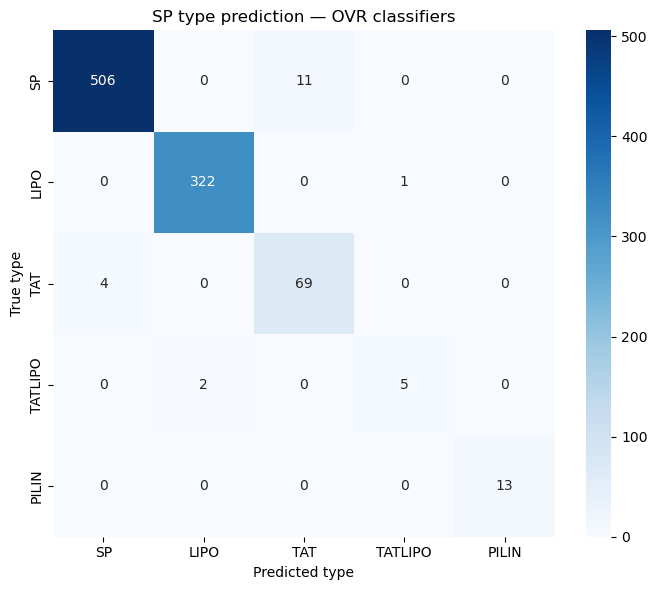

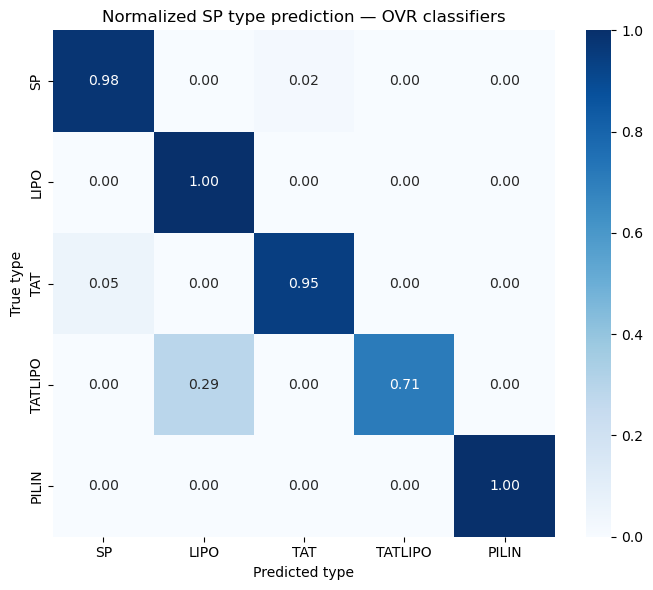

In [18]:
cm = confusion_matrix(
    y_true_type,
    y_pred_type,
    labels=SP_TYPES,
)

cm_df = pd.DataFrame(
    cm,
    index=SP_TYPES,
    columns=SP_TYPES,
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)

plt.xlabel("Predicted type")
plt.ylabel("True type")
plt.title("SP type prediction — OVR classifiers")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "sp_type_ovr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


cm_norm = confusion_matrix(
    y_true_type,
    y_pred_type,
    labels=SP_TYPES,
    normalize="true",
)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=SP_TYPES,
    columns=SP_TYPES,
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
)

plt.xlabel("Predicted type")
plt.ylabel("True type")
plt.title("Normalized SP type prediction — OVR classifiers")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "sp_type_ovr_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 12. Pairwise refiners

Two difficult type boundaries are refined with pairwise CPP classifiers:

- `LIPO` vs `TATLIPO`
- `SP` vs `TAT` (optional)

These refiners are trained only on the relevant pair of SP types and applied only when the OVR prediction falls into the corresponding pair.

In [29]:
## Pairwise refiners

ENABLE_SP_TAT_REFINER = False
PAIR_NEG_POS_RATIO = 10  # use more LIPO negatives than rare TATLIPO positives


def build_pair_dataset(
    df_train: pd.DataFrame,
    type_negative: str,
    type_positive: str,
    neg_pos_ratio: int = PAIR_NEG_POS_RATIO,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    df_pair = df_train[
        df_train["sp_type"].isin([type_negative, type_positive])
    ].copy()

    df_pair["pair_label"] = (
        df_pair["sp_type"] == type_positive
    ).astype(int)

    df_pos = df_pair[df_pair["pair_label"] == 1]
    df_neg = df_pair[df_pair["pair_label"] == 0]

    if len(df_pos) == 0 or len(df_neg) == 0:
        raise ValueError(
            f"Not enough samples for pairwise refiner: "
            f"{type_negative} vs {type_positive}"
        )

    n_neg = min(len(df_neg), len(df_pos) * neg_pos_ratio)

    df_pos_sampled = df_pos.copy()
    df_neg_sampled = df_neg.sample(
        n=n_neg,
        random_state=random_state,
    )

    return (
        pd.concat([df_pos_sampled, df_neg_sampled], ignore_index=True)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )


def train_pair_refiner(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    type_negative: str,
    type_positive: str,
    neg_pos_ratio: int = PAIR_NEG_POS_RATIO,
):
    print(f"\n=== Pairwise refiner: {type_negative} vs {type_positive} ===")

    train_pair = build_pair_dataset(
        df_train,
        type_negative=type_negative,
        type_positive=type_positive,
        neg_pos_ratio=neg_pos_ratio,
        random_state=RANDOM_STATE,
    )

    test_pair = df_test[
        df_test["sp_type"].isin([type_negative, type_positive])
    ].copy()

    test_pair["pair_label"] = (
        test_pair["sp_type"] == type_positive
    ).astype(int)

    print("train:", train_pair["pair_label"].value_counts().to_dict())
    print("test:", test_pair["pair_label"].value_counts().to_dict())

    df_feat_pair = run_cpp_feature_selection(
        train_pair.rename(columns={"pair_label": "ovr_label"})
    )

    X_train_pair = make_feature_matrix(train_pair, df_feat_pair)
    y_train_pair = train_pair["pair_label"].values

    X_test_pair = make_feature_matrix(test_pair, df_feat_pair)
    y_test_pair = test_pair["pair_label"].values

    if XGBClassifier is not None:
        pos = int((y_train_pair == 1).sum())
        neg = int((y_train_pair == 0).sum())

        model = XGBClassifier(
            n_estimators=800,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            scale_pos_weight=neg / max(pos, 1),
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
        )

        model_name = "XGBoost"

    else:
        model = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )

        model_name = "Random Forest"

    model.fit(X_train_pair, y_train_pair)

    y_pred_pair = model.predict(X_test_pair)

    if hasattr(model, "predict_proba"):
        y_proba_pair = model.predict_proba(X_test_pair)[:, 1]
    else:
        y_proba_pair = y_pred_pair

    print(f"Model: {model_name}")
    print(
        classification_report(
            y_test_pair,
            y_pred_pair,
            target_names=[type_negative, type_positive],
            digits=4,
            zero_division=0,
        )
    )

    return {
        "model_name": model_name,
        "model": model,
        "features": df_feat_pair,
        "type_negative": type_negative,
        "type_positive": type_positive,
        "neg_pos_ratio": neg_pos_ratio,
        "train_pair": train_pair,
        "test_pair": test_pair,
        "y_test": y_test_pair,
        "y_pred": y_pred_pair,
        "y_proba": y_proba_pair,
    }


# Main refiner: LIPO vs TATLIPO
refiner_lipo_tatlipo = train_pair_refiner(
    train_sp_df,
    test_sp_df,
    type_negative="LIPO",
    type_positive="TATLIPO",
    neg_pos_ratio=PAIR_NEG_POS_RATIO,
)

joblib.dump(
    refiner_lipo_tatlipo["model"],
    MODEL_DIR / "model_refiner_lipo_vs_tatlipo.pkl",
)


# Optional refiner: SP vs TAT
if ENABLE_SP_TAT_REFINER:
    refiner_sp_tat = train_pair_refiner(
        train_sp_df,
        test_sp_df,
        type_negative="SP",
        type_positive="TAT",
        neg_pos_ratio=PAIR_NEG_POS_RATIO,
    )

    joblib.dump(
        refiner_sp_tat["model"],
        MODEL_DIR / "model_refiner_sp_vs_tat.pkl",
    )


=== Pairwise refiner: LIPO vs TATLIPO ===
train: {0: 260, 1: 26}
test: {0: 323, 1: 7}
Model: XGBoost
              precision    recall  f1-score   support

        LIPO     1.0000    0.9907    0.9953       323
     TATLIPO     0.7000    1.0000    0.8235         7

    accuracy                         0.9909       330
   macro avg     0.8500    0.9954    0.9094       330
weighted avg     0.9936    0.9909    0.9917       330



## 13. Apply pairwise refiners to OVR predictions

In [30]:
def apply_pair_refiner(
    predictions: np.ndarray,
    df_test: pd.DataFrame,
    refiner: dict,
    candidate_pair: set[str],
) -> np.ndarray:
    updated = predictions.copy()

    mask = pd.Series(predictions).isin(candidate_pair).values
    if mask.sum() == 0:
        return updated

    df_subset = df_test.loc[mask].copy()
    X_subset = make_feature_matrix(df_subset, refiner["features"])

    pred_pair = refiner["model"].predict(X_subset)
    mapped = np.where(
        pred_pair == 1,
        refiner["type_positive"],
        refiner["type_negative"],
    )

    updated[mask] = mapped
    return updated


y_pred_type_refined = y_pred_type.copy()

# Main pairwise refinement
y_pred_type_refined = apply_pair_refiner(
    y_pred_type_refined,
    test_sp_df,
    refiner_lipo_tatlipo,
    {"LIPO", "TATLIPO"},
)

# Optional SP vs TAT refinement
if ENABLE_SP_TAT_REFINER:
    y_pred_type_refined = apply_pair_refiner(
        y_pred_type_refined,
        test_sp_df,
        refiner_sp_tat,
        {"SP", "TAT"},
    )

print(
    classification_report(
        y_true_type,
        y_pred_type_refined,
        labels=SP_TYPES,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

          SP     0.9922    0.9787    0.9854       517
        LIPO     1.0000    0.9907    0.9953       323
         TAT     0.8625    0.9452    0.9020        73
     TATLIPO     0.7000    1.0000    0.8235         7
       PILIN     1.0000    1.0000    1.0000        13

    accuracy                         0.9807       933
   macro avg     0.9109    0.9829    0.9412       933
weighted avg     0.9826    0.9807    0.9813       933



## 14. Confusion matrix after refiners

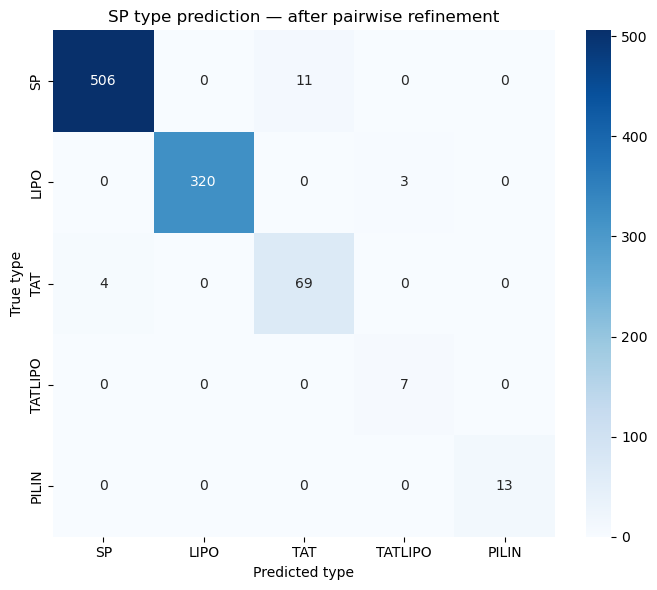

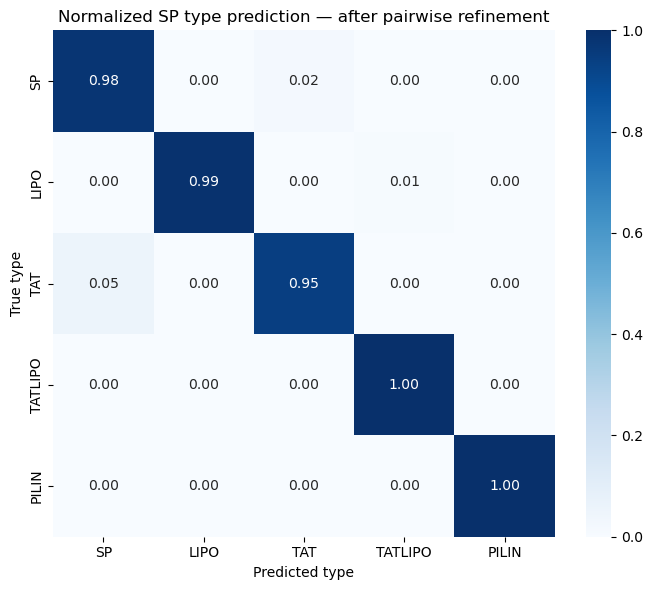

In [32]:
## Refined confusion matrices

cm_refined = confusion_matrix(
    y_true_type,
    y_pred_type_refined,
    labels=SP_TYPES,
)

cm_refined_df = pd.DataFrame(
    cm_refined,
    index=SP_TYPES,
    columns=SP_TYPES,
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_refined_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
)

plt.xlabel("Predicted type")
plt.ylabel("True type")
plt.title("SP type prediction — after pairwise refinement")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "sp_type_refined_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Normalized confusion matrix
cm_refined_norm = confusion_matrix(
    y_true_type,
    y_pred_type_refined,
    labels=SP_TYPES,
    normalize="true",
)

cm_refined_norm_df = pd.DataFrame(
    cm_refined_norm,
    index=SP_TYPES,
    columns=SP_TYPES,
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_refined_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
)

plt.xlabel("Predicted type")
plt.ylabel("True type")
plt.title("Normalized SP type prediction — after pairwise refinement")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "sp_type_refined_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 15. Final metrics

In [33]:
final_type_metrics = {
    "ovr_accuracy": accuracy_score(
        y_true_type,
        y_pred_type,
    ),

    "ovr_macro_f1": f1_score(
        y_true_type,
        y_pred_type,
        average="macro",
    ),

    "ovr_weighted_f1": f1_score(
        y_true_type,
        y_pred_type,
        average="weighted",
    ),

    "refined_accuracy": accuracy_score(
        y_true_type,
        y_pred_type_refined,
    ),

    "refined_macro_f1": f1_score(
        y_true_type,
        y_pred_type_refined,
        average="macro",
    ),

    "refined_weighted_f1": f1_score(
        y_true_type,
        y_pred_type_refined,
        average="weighted",
    ),

    "n_train_sp": int(len(train_sp_df)),
    "n_test_sp": int(len(test_sp_df)),

    "sp_types": SP_TYPES,

    "min_pre_cs_len": MIN_PRE_CS_LEN,
    "post_cs_len": POST_CS_LEN,

    "ovr_neg_pos_ratio": OVR_NEG_POS_RATIO,
    "pair_neg_pos_ratio": PAIR_NEG_POS_RATIO,

    "enable_sp_tat_refiner": ENABLE_SP_TAT_REFINER,

    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "n_runs_benchmark": N_RUNS,
}

metrics_path = METRIC_DIR / "sp_type_final_metrics.json"

with open(metrics_path, "w") as file:
    json.dump(final_type_metrics, file, indent=2)

pd.DataFrame(
    {
        "entry": test_sp_df["entry"].values,
        "true_sp_type": y_true_type,
        "ovr_pred_sp_type": y_pred_type,
        "refined_pred_sp_type": y_pred_type_refined,
    }
).to_csv(
    METRIC_DIR / "sp_type_test_predictions.csv",
    index=False,
)

print(f"Saved final metrics to: {metrics_path}")

final_type_metrics

Saved final metrics to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/results/metrics/sp_type_final_metrics.json


{'ovr_accuracy': 0.9807073954983923,
 'ovr_macro_f1': 0.9303898241730335,
 'ovr_weighted_f1': 0.9808991974981659,
 'refined_accuracy': 0.9807073954983923,
 'refined_macro_f1': 0.9412437837402721,
 'refined_weighted_f1': 0.9812965969197804,
 'n_train_sp': 3729,
 'n_test_sp': 933,
 'sp_types': ['SP', 'LIPO', 'TAT', 'TATLIPO', 'PILIN'],
 'min_pre_cs_len': 5,
 'post_cs_len': 15,
 'ovr_neg_pos_ratio': 8,
 'pair_neg_pos_ratio': 10,
 'enable_sp_tat_refiner': False,
 'test_size': 0.2,
 'random_state': 42,
 'n_runs_benchmark': 10}

### Type-specific CPP interpretation

For each SP type, the selected one-vs-rest CPP features were visualized to inspect type-specific physicochemical differences within the signal peptide family.

Here, “Rest” refers to all other SP types, not non-SP sequences.


=== CPP interpretation: SP vs Rest ===


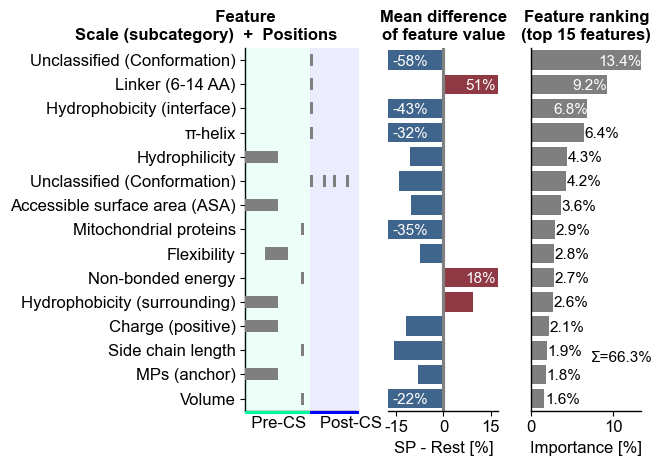

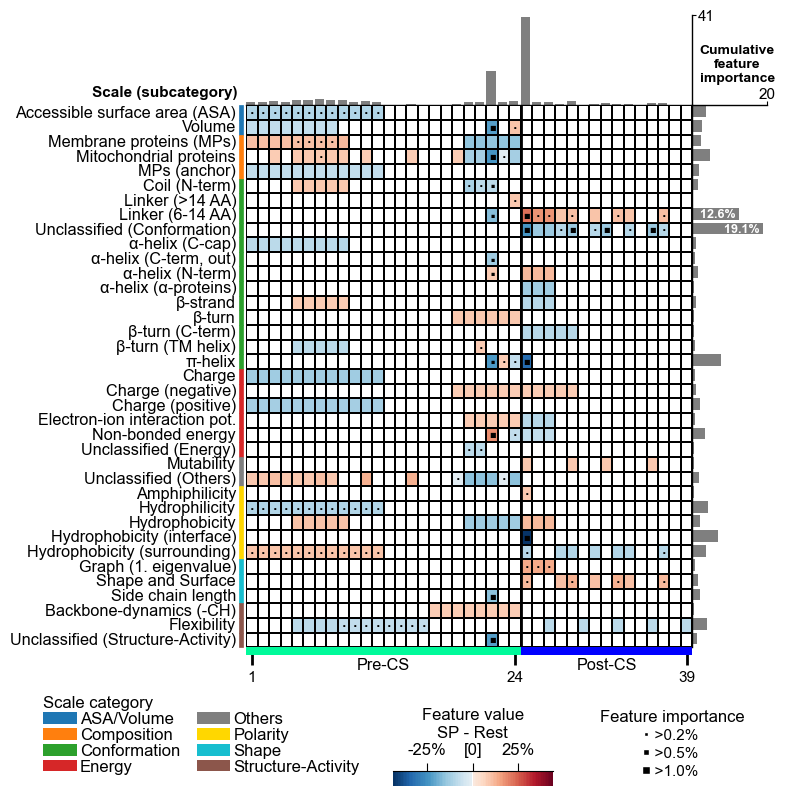


=== CPP interpretation: LIPO vs Rest ===


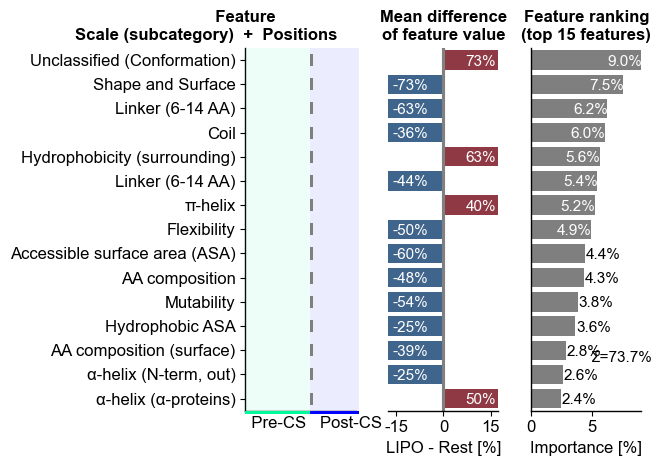

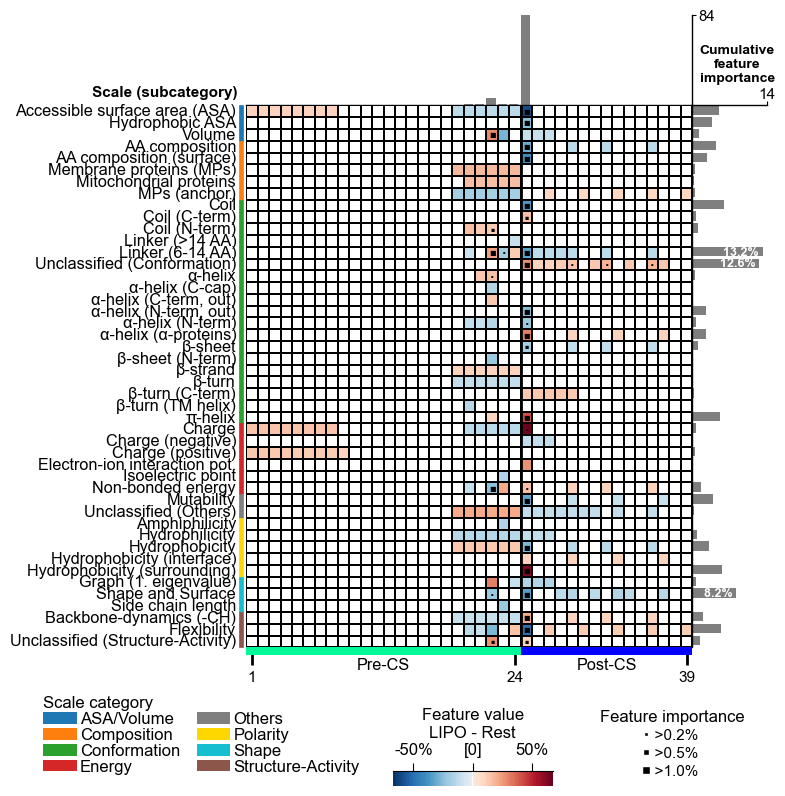


=== CPP interpretation: TAT vs Rest ===


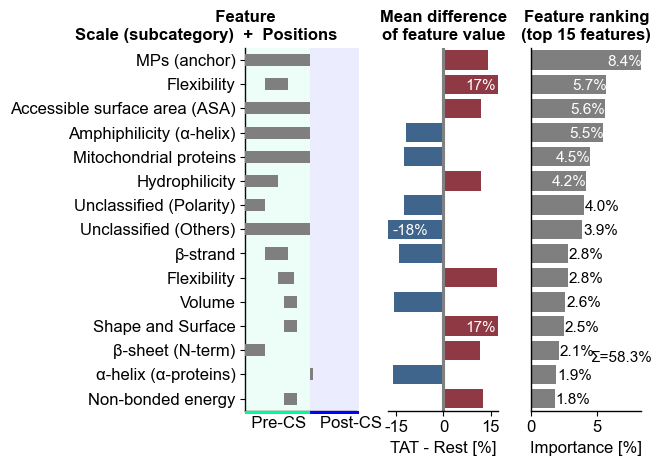

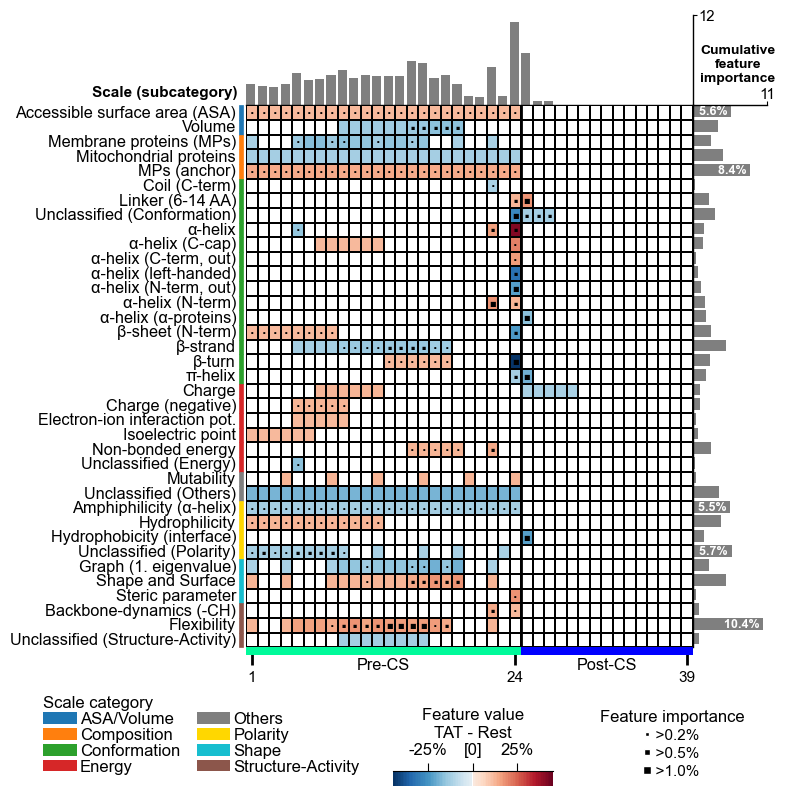


=== CPP interpretation: TATLIPO vs Rest ===


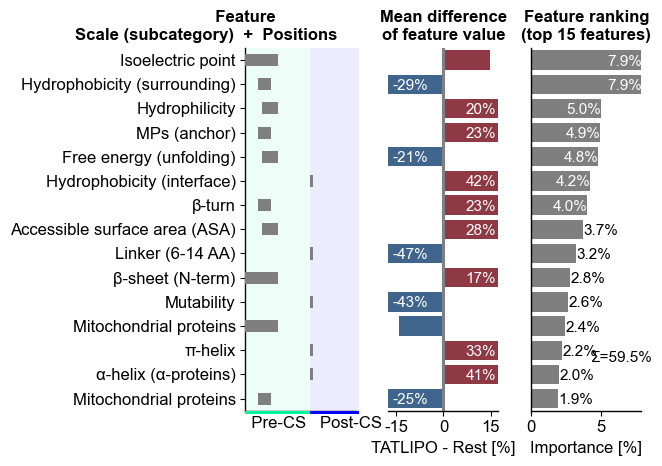

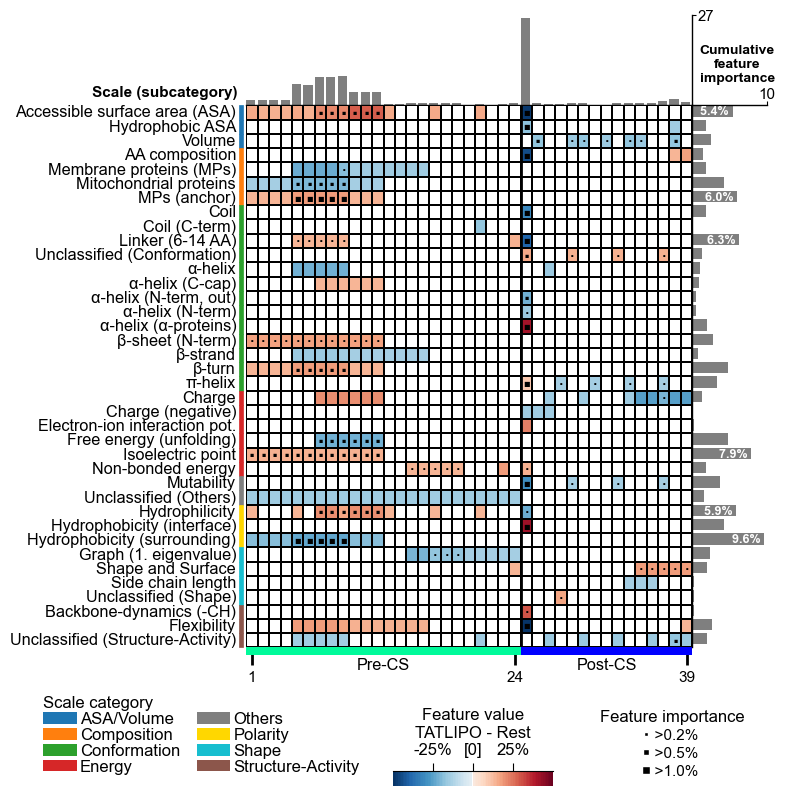


=== CPP interpretation: PILIN vs Rest ===


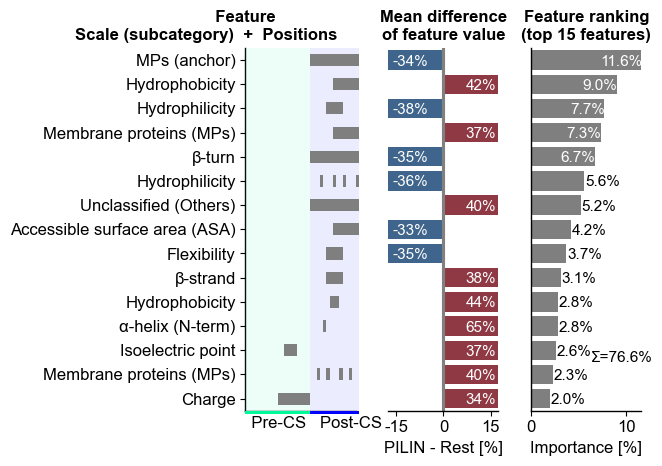

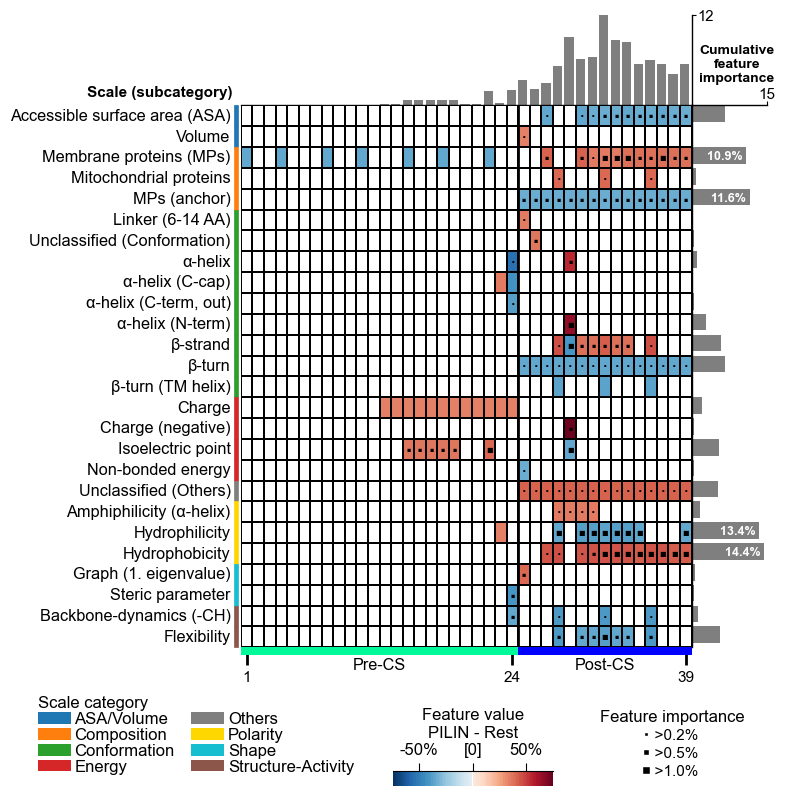

In [34]:
## Type-specific CPP interpretation

import aaanalysis.utils as ut

ut.options["name_tmd"] = "Pre-CS"
ut.options["name_jmd_c"] = "Post-CS"
ut.options["name_jmd_n"] = ""

aa.plot_settings(
    font_scale=0.65,
    weight_bold=False,
)

cpp_plot = aa.CPPPlot(
    jmd_n_len=0,
    jmd_c_len=POST_CS_LEN,
)

for sp_type in SP_TYPES:
    print(f"\n=== CPP interpretation: {sp_type} vs Rest ===")

    df_feat_type = ovr_features[sp_type].copy()

    # Add feature importance for visualization
    X_train_t = ovr_matrices[sp_type]["X_train"]
    y_train_t = ovr_matrices[sp_type]["y_train"]

    try:
        tm = aa.TreeModel()
        tm.fit(X_train_t, labels=y_train_t)
        df_feat_type = tm.add_feat_importance(
            df_feat=df_feat_type,
            drop=True,
        )
    except Exception as exc:
        print(f"Could not add feature importance for {sp_type}: {exc}")

    # Ranking plot
    aa.plot_settings(
        short_ticks=True,
        weight_bold=False,
    )

    cpp_plot.ranking(
        df_feat=df_feat_type,
        name_test=sp_type,
        name_ref="Rest",
    )

    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / f"cpp_ranking_{sp_type}_vs_rest.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    # Feature map
    aa.plot_settings(
        font_scale=0.65,
        weight_bold=False,
    )

    cpp_plot.feature_map(
        df_feat=df_feat_type,
        tmd_len=PRE_CS_LEN_FOR_PLOTS,
        name_test=sp_type,
        name_ref="Rest",
    )

    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / f"cpp_feature_map_{sp_type}_vs_rest.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    df_feat_type.to_csv(
        FEATURE_DIR / "metadata" / f"features_ovr_{sp_type}_with_importance.csv",
        index=False,
    )